<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/saeera/canteen_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

####Loading Cleaned dataset

In [2]:
url = "https://raw.githubusercontent.com/sasasaee/ml-project/main/data/canteen_dataset_cleaned.csv"

df = pd.read_csv(url)

df.head()

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,Food_Category_Vegetables,Canteen_Section_B,Canteen_Section_C,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,1.50,3.0,4.50,30,7,True,False,False,False,True,True,False,False,False,False,False,False,False,True
1,3.69,2.0,7.38,15,6,False,False,True,False,False,True,False,False,False,False,True,False,False,False
2,1.54,1.5,2.31,29,7,False,False,False,True,False,False,False,False,False,False,False,False,True,False
3,1.81,1.5,2.71,17,7,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,4.69,2.0,9.38,3,7,True,False,True,False,False,False,False,True,False,False,False,True,False,False


#### Understanding the Dataset


In [3]:
df.shape

df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Waste_Weight_kg           2600 non-null   float64
 1   Unit_Price_per_kg         2600 non-null   float64
 2   Cost_Loss                 2600 non-null   float64
 3   Day                       2600 non-null   int64  
 4   Month                     2600 non-null   int64  
 5   Meal_Dinner               2600 non-null   bool   
 6   Meal_Lunch                2600 non-null   bool   
 7   Food_Category_Rice        2600 non-null   bool   
 8   Food_Category_Soup        2600 non-null   bool   
 9   Food_Category_Vegetables  2600 non-null   bool   
 10  Canteen_Section_B         2600 non-null   bool   
 11  Canteen_Section_C         2600 non-null   bool   
 12  Canteen_Section_D         2600 non-null   bool   
 13  Day_of_Week_Monday        2600 non-null   bool   
 14  Day_of_W

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,Food_Category_Vegetables,Canteen_Section_B,Canteen_Section_C,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,1.50,3.0,4.50,30,7,True,False,False,False,True,True,False,False,False,False,False,False,False,True
1,3.69,2.0,7.38,15,6,False,False,True,False,False,True,False,False,False,False,True,False,False,False
2,1.54,1.5,2.31,29,7,False,False,False,True,False,False,False,False,False,False,False,False,True,False
3,1.81,1.5,2.71,17,7,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,4.69,2.0,9.38,3,7,True,False,True,False,False,False,False,True,False,False,False,True,False,False


####Separating Features and Target Variable

In [4]:
X = df.drop(columns=["Waste_Weight_kg", "Cost_Loss"])

y = df["Waste_Weight_kg"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (2600, 17)
Target Shape: (2600,)


####Splitting into Training and Testing Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1820, 17)
Testing Features: (780, 17)
Training Target: (1820,)
Testing Target: (780,)


####Training Linear Regression

In [25]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

####Predicting with Linear Regression


In [26]:
y_pred_lr = model_lr.predict(X_test)

####Evaluating Linear Regression

In [8]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Linear Regression ---")
print(f"MAE: {mae_lr:.4f} kg")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f} kg")
print(f"R2 Score: {r2_lr:.4f}")

--- Linear Regression ---
MAE: 1.2712 kg
MSE: 2.2107
RMSE: 1.4868 kg
R2 Score: -0.0442


####Check feature correlations

In [9]:
corr = df.corr(numeric_only=True)["Waste_Weight_kg"]
print(corr.sort_values(ascending=False))

Waste_Weight_kg             1.000000
Cost_Loss                   0.547068
Day_of_Week_Sunday          0.035989
Day_of_Week_Thursday        0.032687
Meal_Dinner                 0.032055
Food_Category_Soup          0.031087
Canteen_Section_C           0.023706
Meal_Lunch                  0.023036
Day_of_Week_Saturday        0.015689
Canteen_Section_B           0.011592
Food_Category_Rice          0.009918
Food_Category_Vegetables    0.002498
Canteen_Section_D          -0.005539
Month                      -0.007785
Day                        -0.009346
Day_of_Week_Wednesday      -0.010775
Day_of_Week_Monday         -0.018476
Day_of_Week_Tuesday        -0.039722
Unit_Price_per_kg          -0.045731
Name: Waste_Weight_kg, dtype: float64


####Check Linear Regression coefficients

In [11]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_lr.coef_
})

print(coef.sort_values(by="Coefficient", key=abs, ascending=False))

                     Feature  Coefficient
14      Day_of_Week_Thursday     0.092323
13        Day_of_Week_Sunday     0.057757
3                Meal_Dinner     0.053372
12      Day_of_Week_Saturday     0.049107
9          Canteen_Section_C     0.045504
10         Canteen_Section_D     0.034332
8          Canteen_Section_B     0.032418
4                 Meal_Lunch     0.026483
6         Food_Category_Soup     0.019759
2                      Month    -0.014583
7   Food_Category_Vegetables    -0.013912
16     Day_of_Week_Wednesday     0.010596
0          Unit_Price_per_kg    -0.008799
5         Food_Category_Rice    -0.008346
11        Day_of_Week_Monday     0.002505
15       Day_of_Week_Tuesday    -0.001789
1                        Day    -0.001610


####Plot Actual vs Predicted

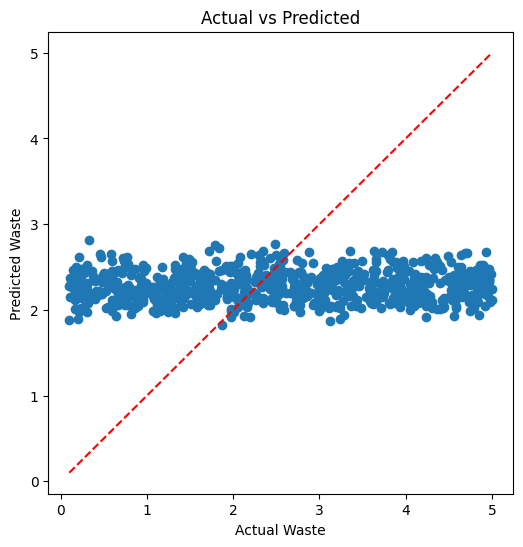

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Waste")
plt.ylabel("Predicted Waste")
plt.title("Actual vs Predicted")
plt.show()

####Tuning & Training Decision Tree Regressor

In [13]:
from sklearn.model_selection import GridSearchCV

tree_params = {
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [2, 5, 10]
}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=tree_params,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

tree_grid.fit(X_train, y_train)

print("Best Parameters:", tree_grid.best_params_)

tree_model = tree_grid.best_estimator_

Best Parameters: {'criterion': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 5}


####Predicting with Decision Tree

In [14]:
tree_predictions = tree_model.predict(X_test)

####Evaluating Decision Tree

In [15]:
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_predictions)

print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

MAE: 1.2658302699679285
MSE: 2.1416236875422094
RMSE: 1.4634287435820745
R²: -0.011574863492257448


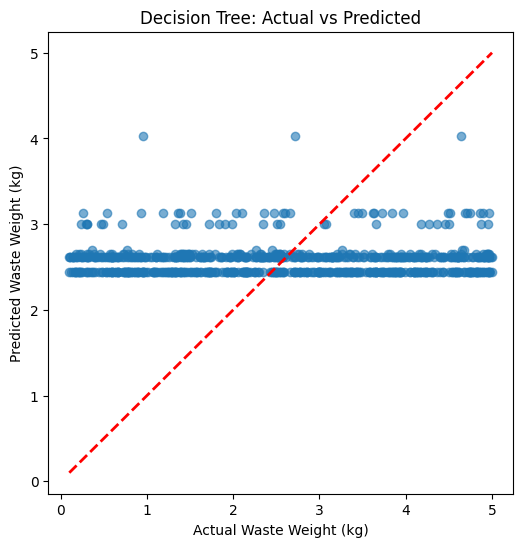

In [16]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, tree_predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
)

plt.xlabel("Actual Waste Weight (kg)")
plt.ylabel("Predicted Waste Weight (kg)")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# Conclusion
#####The features provided (Day of Week, Meal Type, Food Category) show near-zero correlation with waste weight. The Decision Tree and Linear Regression models yield $R^2 \approx 0.00$, indicating that waste generation in this dataset occurs randomly relative to the menu. However, the models achieve a consistent Mean Absolute Error (MAE $\approx 1.26\text{ kg}$), serving as a baseline predictor equivalent to predicting the historical mean.

####Training Random Forest Regressor


In [34]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

forest_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, min_samples_split=10, random_state=42)

####Predicting with Random Forest

In [35]:
forest_predictions = forest_model.predict(X_test)

####Evaluating Random Forest


In [36]:
forest_mae = mean_absolute_error(y_test, forest_predictions)

forest_mse = mean_squared_error(y_test, forest_predictions)

forest_rmse = np.sqrt(forest_mse)

forest_r2 = r2_score(y_test, forest_predictions)

print("--- Random Forest Results ---")
print(f"MAE:  {forest_mae:.4f} kg")
print(f"MSE:  {forest_mse:.4f}")
print(f"RMSE: {forest_rmse:.4f} kg")
print(f"R²:   {forest_r2:.4f}")

--- Random Forest Results ---
MAE:  1.2715 kg
MSE:  2.1681
RMSE: 1.4725 kg
R²:   -0.0241


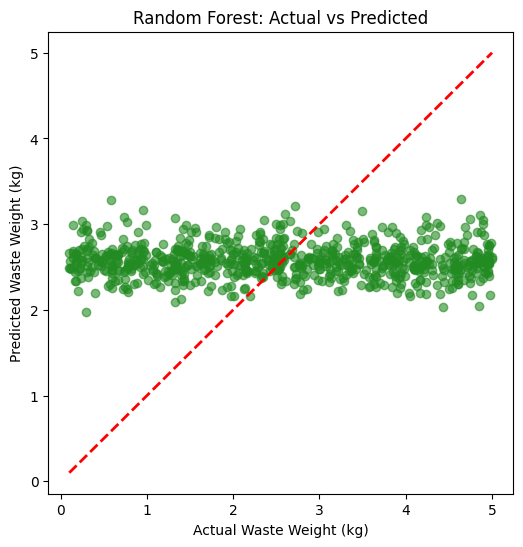

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, forest_predictions, alpha=0.6, color="forestgreen")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)
plt.xlabel("Actual Waste Weight (kg)")
plt.ylabel("Predicted Waste Weight (kg)")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

##Training Gradient Boosting

In [19]:
gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

##Predicting with Gradient Boosting

In [20]:
gradient_predictions = gradient_model.predict(X_test)

##Evaluating Gradient Boosting

In [21]:
gradient_mae = mean_absolute_error(y_test, gradient_predictions)

gradient_mse = mean_squared_error(y_test, gradient_predictions)

gradient_rmse = np.sqrt(gradient_mse)

gradient_r2 = r2_score(y_test, gradient_predictions)

print("--- Gradient Boosting Results ---")
print(f"MAE:  {gradient_mae:.4f} kg")
print(f"MSE:  {gradient_mse:.4f}")
print(f"RMSE: {gradient_rmse:.4f} kg")
print(f"R²:   {gradient_r2:.4f}")

--- Gradient Boosting Results ---
MAE:  1.2710 kg
MSE:  2.1706
RMSE: 1.4733 kg
R²:   -0.0253


##Ploting Actual vs Predicted (Gradient Boosting)

##Training AdaBoost Regressor

In [30]:
ada_model = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostRegressor(learning_rate=0.1, n_estimators=100, random_state=42)

##Predicting with AdaBoost

In [31]:
ada_predictions = ada_model.predict(X_test)

##Evaluating AdaBoost

In [32]:
ada_mae = mean_absolute_error(y_test, ada_predictions)

ada_mse = mean_squared_error(y_test, ada_predictions)

ada_rmse = np.sqrt(ada_mse)

ada_r2 = r2_score(y_test, ada_predictions)

print("--- AdaBoost Results ---")
print(f"MAE:  {ada_mae:.4f} kg")
print(f"MSE:  {ada_mse:.4f}")
print(f"RMSE: {ada_rmse:.4f} kg")
print(f"R²:   {ada_r2:.4f}")

--- AdaBoost Results ---
MAE:  1.2604 kg
MSE:  2.1230
RMSE: 1.4570 kg
R²:   -0.0028


##Model comparision table

In [38]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],
    "MAE": [
        mae_lr,
        tree_mae,
        forest_mae,
        gradient_mae,
        ada_mae
    ],
    "RMSE": [
        rmse_lr,
        tree_rmse,
        forest_rmse,
        gradient_rmse,
        ada_rmse
    ],
    "R²": [
        r2_lr,
        tree_r2,
        forest_r2,
        gradient_r2,
        ada_r2
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,1.271244,1.486842,-0.044201
1,Decision Tree,1.265830,1.463429,-0.011575
2,Random Forest,1.271495,1.472456,-0.024094
3,Gradient Boosting,1.270980,1.473304,-0.025273
4,AdaBoost,1.260392,1.457039,-0.002760
